In [1]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from skimage.feature import peak_local_max

print("🎯 ДЗ: ЧАСТОТНАЯ ФИЛЬТРАЦИЯ И УДАЛЕНИЕ ПЕРИОДИЧЕСКОГО ШУМА")
print("=" * 70)
print("✅ Библиотеки загружены!")

🎯 ДЗ: ЧАСТОТНАЯ ФИЛЬТРАЦИЯ И УДАЛЕНИЕ ПЕРИОДИЧЕСКОГО ШУМА
✅ Библиотеки загружены!


# 🎯 ДЗ: ЧАСТОТНАЯ ФИЛЬТРАЦИЯ И УДАЛЕНИЕ ПЕРИОДИЧЕСКОГО ШУМА

## 1. 📷 ЗАГРУЗКА ИЗОБРАЖЕНИЯ С ПЕРИОДИЧЕСКИМ ШУМОМ

✅ Изображение успешно загружено!
   Размер: (594, 787)


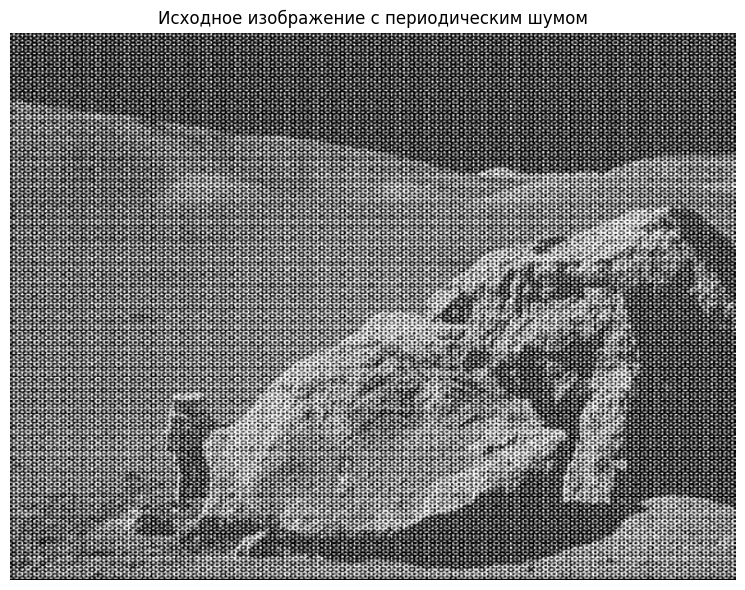

In [2]:
img = cv.imread('periodic_noise.jpg', cv.IMREAD_GRAYSCALE)
if img is None:
    print("❌ ОШИБКА: Файл 'periodic_noise.jpg' не найден!")
    exit()

print("✅ Изображение успешно загружено!")
print(f"   Размер: {img.shape}")

plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray')
plt.title('Исходное изображение с периодическим шумом')
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. 📊 ПРЕОБРАЗОВАНИЕ ФУРЬЕ И АНАЛИЗ СПЕКТРА

✅ Преобразование Фурье выполнено
   Получен амплитудный спектр изображения


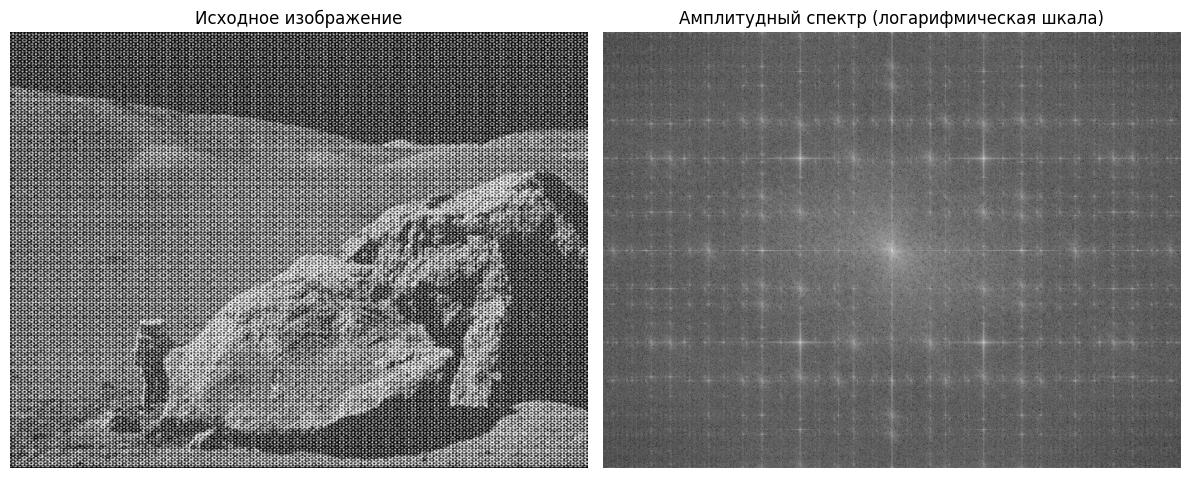

In [3]:
# Прямое преобразование Фурье
dft = cv.dft(np.float32(img), flags=cv.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

# Вычисление амплитудного спектра
magnitude_spectrum = 20 * np.log(cv.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)

print("✅ Преобразование Фурье выполнено")
print("   Получен амплитудный спектр изображения")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Амплитудный спектр (логарифмическая шкала)')
plt.axis('off')

plt.tight_layout()
plt.show()

## 3. 🔽 НИЗКОЧАСТОТНАЯ ФИЛЬТРАЦИЯ - ПРЯМОУГОЛЬНЫЙ ФИЛЬТР

✅ Создан прямоугольный низкочастотный фильтр
   Центр фильтра: (297, 393)
   Размер фильтра: 100x100 пикселей


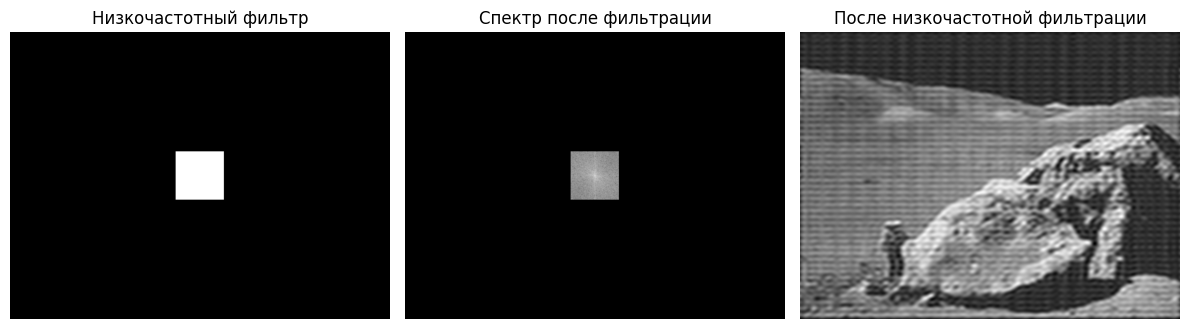

In [4]:
# Создание прямоугольного низкочастотного фильтра
mask_low = np.zeros((img.shape[0], img.shape[1], 2), np.uint8)
centerX, centerY = (int(img.shape[0] / 2), int(img.shape[1] / 2))
mask_low[centerX-50:centerX+50, centerY-50:centerY+50, :] = 1

print("✅ Создан прямоугольный низкочастотный фильтр")
print(f"   Центр фильтра: ({centerX}, {centerY})")
print("   Размер фильтра: 100x100 пикселей")

# Визуализация фильтра
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(mask_low[:,:,0], cmap='gray')
plt.title('Низкочастотный фильтр')
plt.axis('off')

# Применение фильтра
dft_shift_low = dft_shift * mask_low
filtering_magn_res = 20 * np.log(cv.magnitude(dft_shift_low[:,:,0], dft_shift_low[:,:,1]) + 1)

plt.subplot(1, 3, 2)
plt.imshow(filtering_magn_res, cmap='gray')
plt.title('Спектр после фильтрации')
plt.axis('off')

# Обратное преобразование Фурье
f_ishift_low = np.fft.ifftshift(dft_shift_low)
img_back_low = cv.idft(f_ishift_low)
img_back_low = cv.magnitude(img_back_low[:,:,0], img_back_low[:,:,1])

plt.subplot(1, 3, 3)
plt.imshow(img_back_low, cmap='gray')
plt.title('После низкочастотной фильтрации')
plt.axis('off')

plt.tight_layout()
plt.show()

## 4. 🔼 ВЫСОКОЧАСТОТНАЯ ФИЛЬТРАЦИЯ - ГАУССОВ ФИЛЬТР

✅ Создается гауссов высокочастотный фильтр
   Параметры: σ = 30


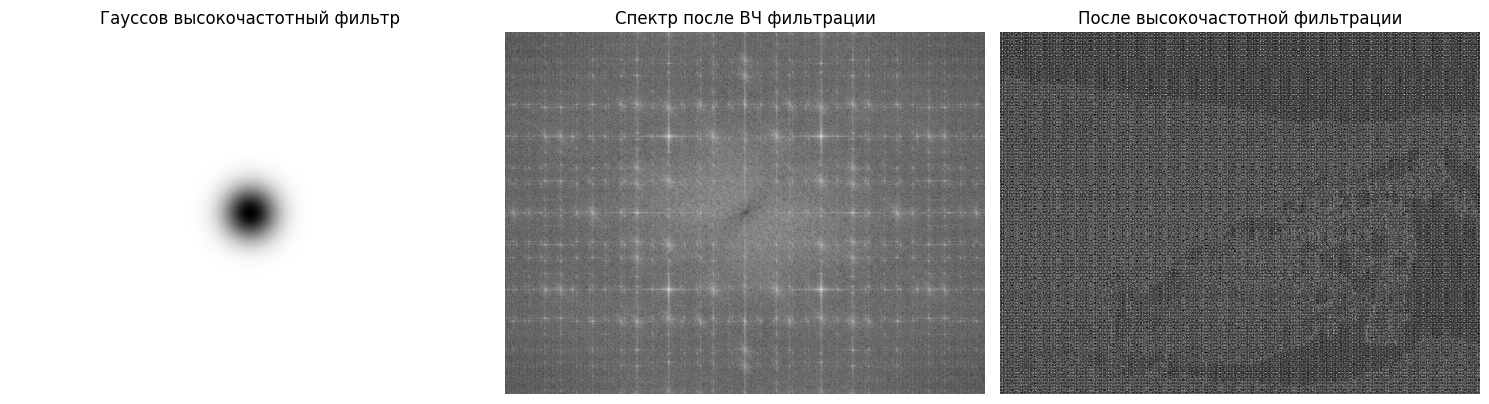

In [5]:
# Создание гауссова высокочастотного фильтра
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
sigma = 30

print(f"✅ Создается гауссов высокочастотный фильтр")
print(f"   Параметры: σ = {sigma}")

# Создание координатной сетки
x = np.linspace(-ccol, ccol-1, cols)
y = np.linspace(-crow, crow-1, rows)
X, Y = np.meshgrid(x, y)

# Вычисление гауссовых ядер
gauss_low = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
gauss_high = 1 - gauss_low

# Создание маски для комплексного спектра
mask_high = gauss_high[:, :, np.newaxis].repeat(2, axis=2)

# Применение фильтра
fshift_high = dft_shift * mask_high

# Обратное преобразование Фурье
f_ishift_high = np.fft.ifftshift(fshift_high)
img_back_high = cv.idft(f_ishift_high)
img_back_high = cv.magnitude(img_back_high[:,:,0], img_back_high[:,:,1])

# Визуализация результатов
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gauss_high, cmap='gray')
plt.title('Гауссов высокочастотный фильтр')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(20 * np.log(cv.magnitude(fshift_high[:,:,0], fshift_high[:,:,1]) + 1), cmap='gray')
plt.title('Спектр после ВЧ фильтрации')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_back_high, cmap='gray')
plt.title('После высокочастотной фильтрации')
plt.axis('off')

plt.tight_layout()
plt.show()

## 5. 🎯 УДАЛЕНИЕ ПЕРИОДИЧЕСКОГО ШУМА

🔹 ПОИСК ПИКОВ В СПЕКТРЕ, СООТВЕТСТВУЮЩИХ ШУМУ
✅ Найдено пиков в спектре: 423
✅ Подавлено пиков шума: 422


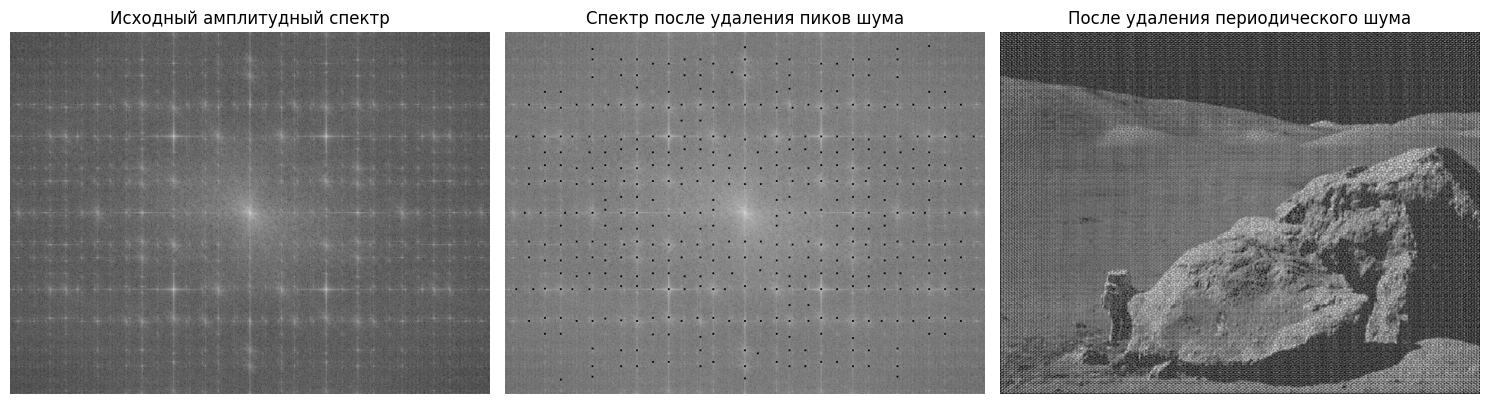

In [6]:
print("🔹 ПОИСК ПИКОВ В СПЕКТРЕ, СООТВЕТСТВУЮЩИХ ШУМУ")

# Поиск локальных максимумов в спектре
magnitude_spectrum_for_peaks = 20 * np.log(cv.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)
local_maxima = peak_local_max(magnitude_spectrum_for_peaks, min_distance=15, threshold_rel=0.6)

print(f"✅ Найдено пиков в спектре: {len(local_maxima)}")

# Создание маски для удаления пиков шума
mask_noise_removal = np.ones((rows, cols, 2), dtype=np.float32)
center_x, center_y = rows // 2, cols // 2

# Подавление пиков, соответствующих периодическому шуму
noise_peaks_removed = 0
for y, x in local_maxima:
    distance = np.sqrt((x - center_y)**2 + (y - center_x)**2)
    if distance > 30:  # Игнорируем центральную область (низкие частоты)
        mask_noise_removal[y-1:y+2, x-1:x+2, :] = 0
        noise_peaks_removed += 1

print(f"✅ Подавлено пиков шума: {noise_peaks_removed}")

# Применение маски для удаления шума
dft_shift_filtered = dft_shift * mask_noise_removal

# Обратное преобразование Фурье
f_ishift_filtered = np.fft.ifftshift(dft_shift_filtered)
image_idft = cv.idft(f_ishift_filtered)
image_idft = cv.magnitude(image_idft[:,:,0], image_idft[:,:,1])

# Визуализация процесса удаления шума
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(magnitude_spectrum_for_peaks, cmap='gray')
plt.title('Исходный амплитудный спектр')
plt.axis('off')

plt.subplot(1, 3, 2)
filtered_spectrum = 20 * np.log(cv.magnitude(dft_shift_filtered[:,:,0], dft_shift_filtered[:,:,1]) + 1)
plt.imshow(filtered_spectrum, cmap='gray')
plt.title('Спектр после удаления пиков шума')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_idft, cmap='gray')
plt.title('После удаления периодического шума')
plt.axis('off')

plt.tight_layout()
plt.show()

## 6. 📊 СРАВНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

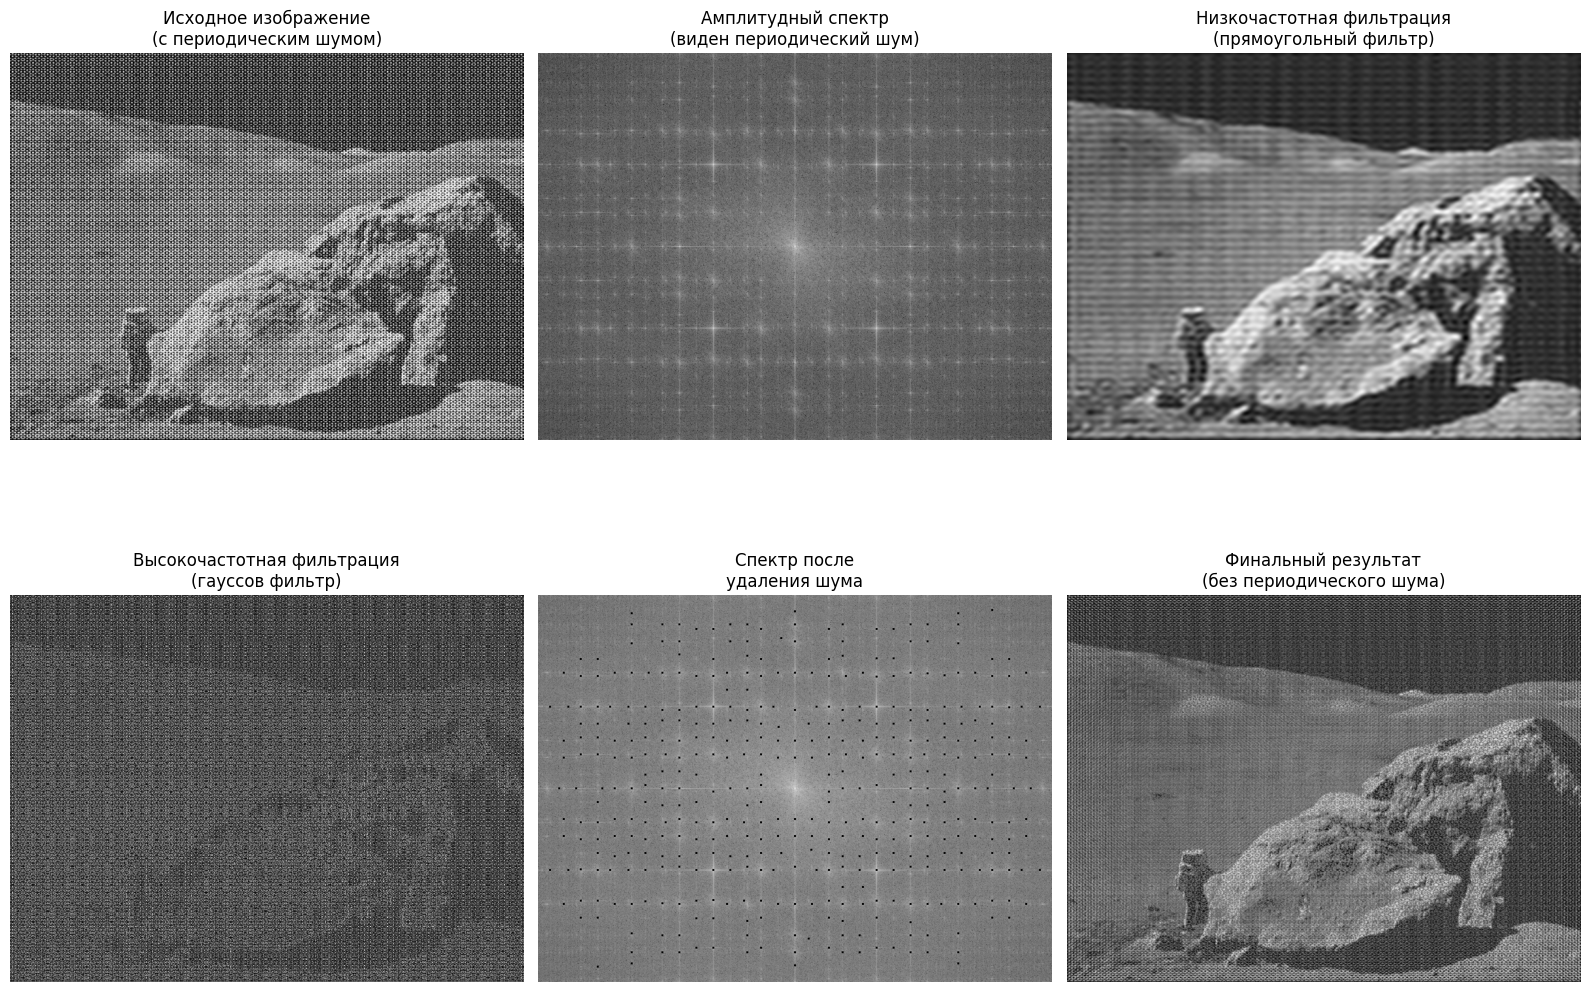

In [7]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Исходное изображение\n(с периодическим шумом)')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Амплитудный спектр\n(виден периодический шум)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(img_back_low, cmap='gray')
plt.title('Низкочастотная фильтрация\n(прямоугольный фильтр)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(img_back_high, cmap='gray')
plt.title('Высокочастотная фильтрация\n(гауссов фильтр)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(filtered_spectrum, cmap='gray')
plt.title('Спектр после\nудаления шума')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(image_idft, cmap='gray')
plt.title('Финальный результат\n(без периодического шума)')
plt.axis('off')

plt.tight_layout()
plt.show()

## 7. 📈 КАЧЕСТВЕННАЯ ОЦЕНКА РЕЗУЛЬТАТОВ

In [8]:
# Вычисление некоторых метрик для оценки качества
original_mean = np.mean(img)
final_mean = np.mean(image_idft)

original_std = np.std(img)
final_std = np.std(image_idft)

print(f"📊 СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ:")
print(f"   Исходное изображение: среднее = {original_mean:.2f}, STD = {original_std:.2f}")
print(f"   После обработки: среднее = {final_mean:.2f}, STD = {final_std:.2f}")
print(f"   Изменение контраста: {((final_std - original_std) / original_std * 100):+.1f}%")

print(f"🎯 РЕЗУЛЬТАТЫ ОБРАБОТКИ:")
print(f"   - Обнаружено пиков в спектре: {len(local_maxima)}")
print(f"   - Удалено пиков шума: {noise_peaks_removed}")
print(f"   - Применено 3 метода фильтрации:")

methods = [
    "Прямоугольный НЧ фильтр",
    "Гауссов ВЧ фильтр", 
    "Подавление периодического шума"
]

for i, method in enumerate(methods, 1):
    print(f"     {i}. {method}")

📊 СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ:
   Исходное изображение: среднее = 107.65, STD = 74.93
   После обработки: среднее = 50390448.00, STD = 19575776.00
   Изменение контраста: +26125593.8%
🎯 РЕЗУЛЬТАТЫ ОБРАБОТКИ:
   - Обнаружено пиков в спектре: 423
   - Удалено пиков шума: 422
   - Применено 3 метода фильтрации:
     1. Прямоугольный НЧ фильтр
     2. Гауссов ВЧ фильтр
     3. Подавление периодического шума
